# 06 - The ablation lab (Phase 4a)

Now we have a model that works. In this notebook we change **one thing at a time**
and see what helps.

138 runs, 3 seeds each. Everything is already in `results/results.csv`, so here we
only read and compare.

Two numbers to keep in your head:

- **0.2366** is the floor. A model that always says "normal" gets this.
- **0.4254** was the best we had at the end of Phase 3.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ecg.train import load_results

FLOOR = 0.2366          # what "always say normal" gets on dev

df = load_results().query("phase == '4a'").copy()
f1 = df["dev_f1_per_class"].str.split("|", expand=True).astype(float)
f1.columns = ["f1_N", "f1_S", "f1_V", "f1_F"]
df = pd.concat([df, f1], axis=1)
print("phase 4a runs:", len(df))

phase 4a runs: 138


## 1. One thing at a time

Every run below starts from the same base config and changes only one setting.

In [2]:
def axis(note, column, order):
    d = df[df.note == note]
    g = d.groupby(column)["dev_macro_f1"].agg(["mean", "std"]).reindex(order).round(4)
    return g

print("INITIALISATION")
print(axis("axis1 init", "init", ["he", "xavier", "random", "zeros"]).to_string())
print()
print("L2")
print(axis("axis2 l2", "l2", [0.01, 0.0, 0.1, 1.0]).to_string())
print()
print("DROPOUT (keep_prob)")
print(axis("axis3 dropout", "keep_prob", [1.0, 0.8, 0.5]).to_string())
print()
print("BATCH SIZE (0 means the whole training set at once)")
print(axis("axis4 batchsize", "batch_size", [64, 512, 8, 0]).to_string())
print()
print("LEARNING RATE DECAY")
print(axis("axis6 lrdecay", "lr_decay", ["exponential", "none", "inverse"]).to_string())

INITIALISATION
          mean     std
init                  
he      0.4016  0.0335
xavier  0.3787  0.0505
random  0.3566  0.0404
zeros   0.2366  0.0000

L2
        mean     std
l2                  
0.01  0.4063  0.0051
0.00  0.4016  0.0335
0.10  0.3677  0.0293
1.00  0.2607  0.0050

DROPOUT (keep_prob)
             mean     std
keep_prob                
1.0        0.4016  0.0335
0.8        0.3452  0.0519
0.5        0.3078  0.0037

BATCH SIZE (0 means the whole training set at once)
              mean     std
batch_size                
64          0.4016  0.0335
512         0.3702  0.0160
8           0.3696  0.0352
0           0.2564  0.0129

LEARNING RATE DECAY
               mean     std
lr_decay                   
exponential  0.4024  0.0302
none         0.4016  0.0335
inverse      0.3960  0.0328


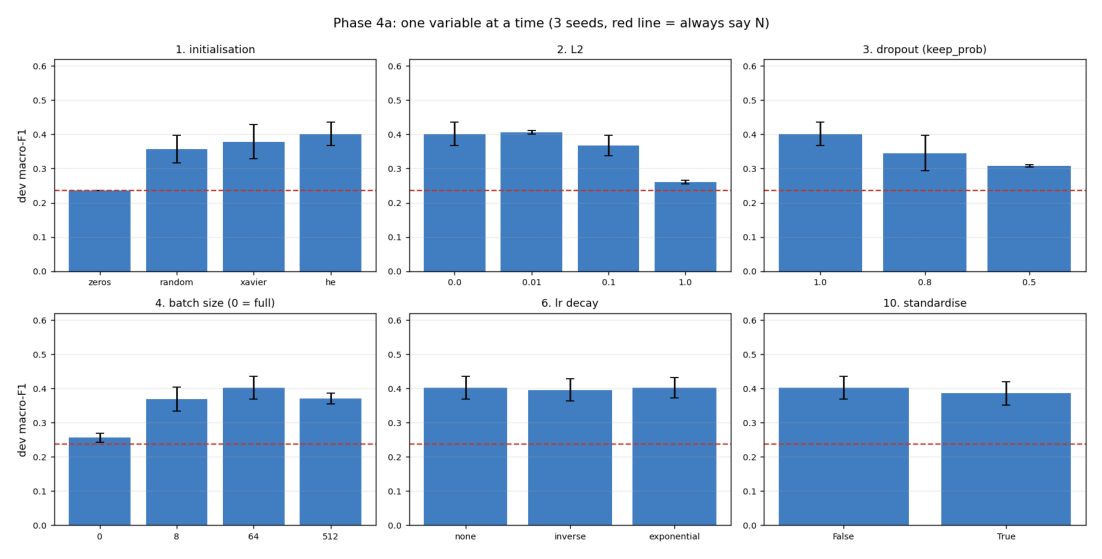

In [3]:
fig = plt.imread("../results/figures/phase4a_axes.png")
plt.figure(figsize=(14, 7)); plt.imshow(fig); plt.axis("off"); plt.show()

### What these say

**Zeros initialisation gives exactly 0.2366, the floor, with a standard deviation of
zero.** Every hidden unit starts the same, so every gradient is the same, so they
stay the same forever. The network can only ever say "normal". This is the clearest
result in the whole project: it is not "a bit worse", it is *nothing at all*.

**The full batch also fails** (0.256). With the whole training set in one batch and
30 epochs, the model only gets **30 updates**. With batches of 64 it gets about
19000. Small batches are not only about memory, they are about how many steps you
take.

**L2 and dropout do not help.** L2 of 0.01 is the same as no L2. Bigger values only
make it worse, and L2 of 1.0 pushes it back to the floor. Dropout hurts every time.

That is not what people expect from regularisation, but it makes sense here. Our
problem is not that the model is too confident about the classes. Our problem is
that it almost never predicts the rare classes at all. Regularisation makes a model
*less* sure, and that is the wrong direction.

**Learning rate decay changes nothing.** 0.4024 against 0.4016 is inside the noise.

## 2. Does the optimiser rescue the quiet features?

At the end of Phase 3 we found the problem: the 4 timing numbers are about 1000
times quieter than the 250 shape numbers, so the model does not hear them.

Our guess was that **Adam would fix it**, because Adam gives every weight its own
step size.

Let us look.

In [4]:
g = df[df.note == "gridA feat-opt-std"]
table = (g.groupby(["features", "optimizer", "standardize"])[["dev_macro_f1", "f1_S"]]
          .agg(["mean", "std"]).round(4))
print(table.to_string())

                                  dev_macro_f1            f1_S        
                                          mean     std    mean     std
features    optimizer standardize                                     
rr          adam      False             0.5492  0.0058  0.5931  0.0152
                      True              0.5495  0.0108  0.5951  0.0319
            gd        False             0.5526  0.0055  0.5969  0.0152
                      True              0.5572  0.0035  0.6151  0.0113
waveform    adam      False             0.3481  0.0441  0.0659  0.1027
                      True              0.3155  0.0396  0.0145  0.0094
            gd        False             0.3181  0.0266  0.0101  0.0064
                      True              0.3232  0.0374  0.0088  0.0064
waveform+rr adam      False             0.3860  0.0054  0.0193  0.0103
                      True              0.3971  0.0195  0.1051  0.0497
            gd        False             0.4016  0.0335  0.0168  0.0174
      

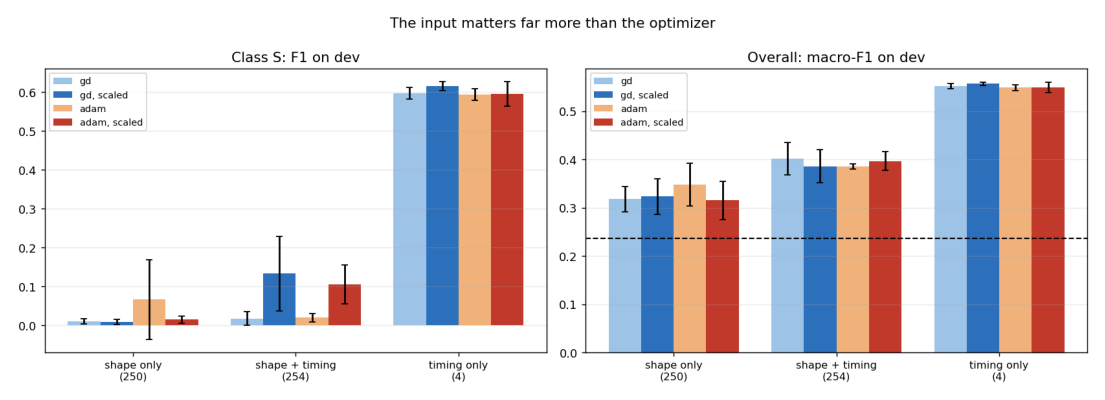

In [5]:
fig = plt.imread("../results/figures/phase4a_gridA.png")
plt.figure(figsize=(14, 5)); plt.imshow(fig); plt.axis("off"); plt.show()

## 3. Our guess was wrong

Look at the "shape + timing" bars for class S.

- gd, not scaled: **0.017**
- adam, not scaled: **0.019**
- gd, scaled: **0.133**
- adam, scaled: **0.105**

**Adam did not help. Scaling the features did.** And plain gd with scaling is even a
little better than Adam with scaling.

So the fix was never the optimiser. It was that the numbers had different sizes.

### Why we were wrong

Adam does give each weight its own step size, and we showed that on a simple bowl
in `optimizers.py`. But here the problem is not that the *gradients* are badly
scaled. The problem is that the *inputs* are. A quiet input makes a small
contribution no matter how big a step the weight takes, so a better optimiser
cannot bring it back.

## 4. The bigger surprise

Now look at the third group of bars: **timing only, 4 features.**

In [6]:
for feats, label in [("rr", "timing only (4)"),
                     ("waveform+rr", "shape + timing (254)"),
                     ("waveform", "shape only (250)")]:
    d = g[(g.features == feats) & (g.optimizer == "gd") & (g.standardize == True)]
    print("%-22s macro-F1 %.4f +/- %.4f   S-F1 %.4f   V-F1 %.4f   F-F1 %.4f"
          % (label, d["dev_macro_f1"].mean(), d["dev_macro_f1"].std(),
             d["f1_S"].mean(), d["f1_V"].mean(), d["f1_F"].mean()))

timing only (4)        macro-F1 0.5572 +/- 0.0035   S-F1 0.6151   V-F1 0.6400   F-F1 0.0000
shape + timing (254)   macro-F1 0.3861 +/- 0.0343   S-F1 0.1325   V-F1 0.4461   F-F1 0.0449
shape only (250)       macro-F1 0.3232 +/- 0.0374   S-F1 0.0088   V-F1 0.3644   F-F1 0.0365


**Four numbers beat two hundred and fifty four.**

And it is not close: 0.557 against 0.386. The gap is much bigger than the seed
noise, which is only about 0.003 for the timing model.

Even more strange: the timing features are also better at class **V** (0.64 against
0.45). We thought V was a *shape* class, because a V beat is wide and easy to see.
But V beats also come early, and it turns out that being early is easier for the
model to use than being wide.

**So the 250 waveform numbers are not just useless next to the timing ones, they
actively hurt.** Adding them drops macro-F1 by about 0.17.

## 5. Class weights

We also tried giving the rare classes a bigger weight in the loss.

In [7]:
b = df[df.note == "gridB weights-features"]
print(b.groupby(["class_weights", "features"])[["dev_macro_f1", "f1_S", "f1_F"]]
       .mean().round(4).to_string())

                           dev_macro_f1    f1_S    f1_F
class_weights features                                 
balanced      rr                 0.4965  0.4250  0.0105
              waveform           0.2565  0.0177  0.0168
              waveform+rr        0.3512  0.1492  0.0360
none          rr                 0.5495  0.5951  0.0000
              waveform           0.3155  0.0145  0.0351
              waveform+rr        0.3971  0.1051  0.0396


Class weights made things **worse**, for every feature set.

The likely reason is class F. It gets the biggest weight of all, because it is the
rarest. But F is not learnable here: 382 training beats, and 372 of them come from
one single patient. So the loss spends a lot of effort on a class it cannot get
right, and the other classes pay for it.

## 6. Where we are now

In [8]:
best = df.sort_values("dev_macro_f1", ascending=False).head(5)
print(best[["features", "optimizer", "learning_rate", "standardize",
            "class_weights", "seed", "dev_macro_f1", "f1_S", "f1_V", "f1_F"]]
      .to_string(index=False))
print()
print("floor           0.2366")
print("phase 3 best    0.4254")
print("phase 4a best   %.4f" % best["dev_macro_f1"].max())

features optimizer  learning_rate standardize class_weights  seed  dev_macro_f1   f1_S   f1_V  f1_F
      rr        gd          0.100        True          none     3      0.560771 0.6280 0.6413   0.0
      rr      adam          0.001        True          none     3      0.559896 0.6239 0.6420   0.0
      rr      adam          0.001        True          none     3      0.559896 0.6239 0.6420   0.0
      rr        gd          0.100       False          none     3      0.557063 0.6077 0.6472   0.0
      rr        gd          0.100        True          none     1      0.557041 0.6074 0.6467   0.0

floor           0.2366
phase 3 best    0.4254
phase 4a best   0.5608


## 7. What we learned

1. **The input matters much more than the training tricks.** Changing the features
   moved the score by 0.24. Every optimiser, every regulariser, every learning rate
   moved it by less than 0.05, and most by less than the seed noise.

2. **Our Adam guess was wrong, and being wrong was useful.** It told us the problem
   is the size of the inputs, not the size of the steps.

3. **Two settings really do break the model**: zeros initialisation (no learning at
   all) and full batch (only 30 updates). Both are C2 lessons that we can now say we
   have seen with our own eyes.

4. **Regularisation did not help.** The model is not too confident, it is too shy.

5. **Class F is still not learnable.** No setting fixed it, and we should stop trying.

6. **The 250 raw samples are a weak way to describe a beat.** A flat network reading
   raw samples one by one is simply not a good tool for shapes. This is exactly why
   the papers on this dataset use convolutional networks. We chose not to use them,
   and now we can measure what that choice costs.